In [ ]:
from IPython.display import clear_output
!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/7fvgj4jsp7-1.zip
!unzip 7fvgj4jsp7-1.zip
!rm 7fvgj4jsp7-1.zip
clear_output()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skimage
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
data_dir = "/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/images"
mask_dir = "/content/BUS-UCLM Breast ultrasound lesion segmentation dataset/BUS-UCLM/masks"
info = pd.read_csv("/content/INFO.csv", sep = ';')

data_lst = os.listdir(data_dir)

In [ ]:
info

,Image,Resolution,Label,Doppler,Marks,Combined
0,ALWI_000.png,856x606,Benign,No,Yes,No
1,ALWI_001.png,856x606,Normal,No,No,No
2,ALWI_002.png,856x606,Benign,No,No,No
3,ALWI_003.png,856x606,Benign,No,No,No
4,ALWI_004.png,856x606,Benign,No,Yes,No
...,...,...,...,...,...,...
678,WAQU_003.png,856x606,Normal,No,No,No
679,WAQU_004.png,856x606,Normal,No,No,No
680,WAQU_005.png,856x606,Normal,No,No,No
681,WAQU_006.png,856x606,Normal,No,No,No


In [ ]:
def ret_binary(mask):
  return ((mask[:, :, 0] > 0) | (mask[:, :, 1] > 0) | (mask[:, :, 2] > 0))

def get_data(im_name, data_dir, mask_dir, info):
  im = plt.imread(os.path.join(data_dir, im_name))
  im = skimage.color.rgb2gray(im) # original data is in rgb
  mask = plt.imread(os.path.join(mask_dir, im_name))
  mask = ret_binary(mask)
  label = info[info['Image'] == im_name]['Label'].item()

  return im, mask, label

def show_overlay(image, mask, alpha=0.5):
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap = 'gray')  # show image
    plt.imshow(mask, cmap='Reds', alpha=alpha)  # overlay mask
    plt.axis('off')
    plt.show();

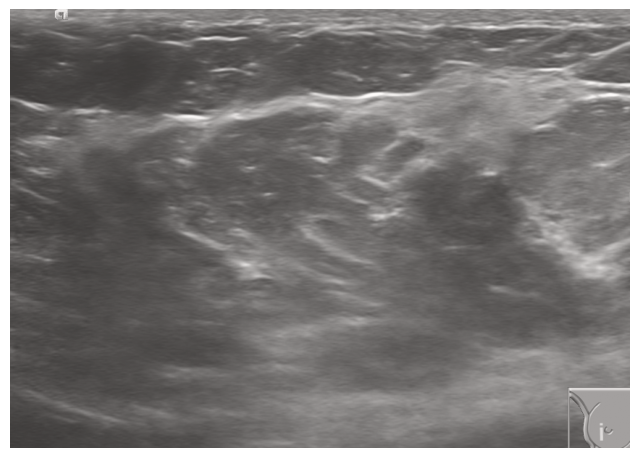

Normal


In [ ]:
random_img = np.random.choice(data_lst).item()
im, mask, label = get_data(random_img, data_dir, mask_dir, info)
show_overlay(im, mask, alpha = 0.25)
print(label)

In [ ]:
def read_data(data_lst, data_dir, mask_dir, info, reshape = True):
  x = []
  y_label = []
  y_mask = []
  for im_name in data_lst:
    im, mask, label = get_data(im_name, data_dir, mask_dir, info)
    if reshape:
      im = skimage.transform.resize(im, (600, 600), anti_aliasing=True)
      mask = skimage.transform.resize(mask, (600, 600), anti_aliasing=False)
    x.append(im)
    y_mask.append(mask)
    y_label.append(label)
  return np.array(x), np.array(y_mask), np.array(y_label)

In [ ]:
x, y_mask, y_label = read_data(data_lst, data_dir, mask_dir, info)

label_map = {'Normal': 0, 'Benign': 1, 'Malignant': 2}

y = np.array([label_map[label] for label in y_label])

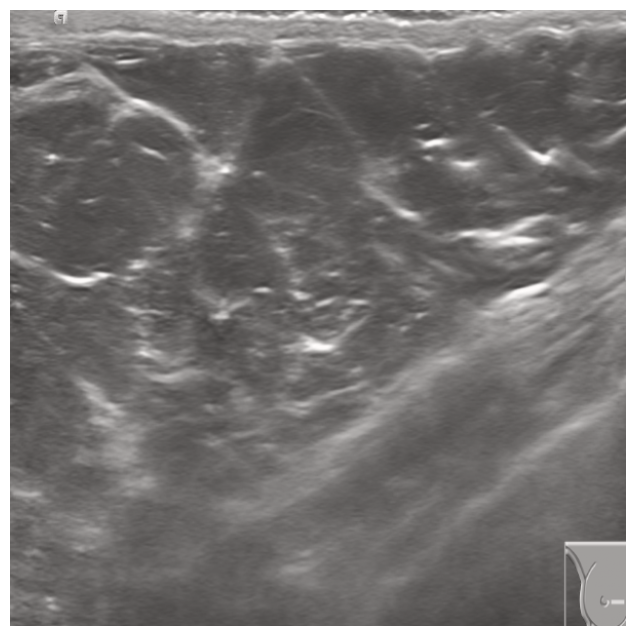

Normal
0


In [ ]:
rand_ind = np.random.randint(0, len(data_lst))
show_overlay(x[rand_ind], y_mask[rand_ind], alpha = 0.25)
print(y_label[rand_ind])
print(y[rand_ind])

In [ ]:
train_idx, test_idx = train_test_split(np.arange(len(y)), test_size=0.1, stratify=y,random_state=125)

x_train = x[train_idx]
x_test = x[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
y_mask_train = y_mask[train_idx]
y_mask_test = y_mask[test_idx]

x_train = (x_train - x_train.mean(axis = 0, keepdims = True))/(x_train.std(axis = 0, keepdims = True) + 1e-4)
x_test = (x_test - x_test.mean(axis = 0, keepdims = True))/(x_test.std(axis = 0, keepdims = True) + 1e-4)

In [ ]:
class BatchLoader():
    def __init__(self, x, y_mask, y_label, shuffle = True, batch_size = 32, device = 'cpu'):
        self.x = x
        self.y_mask = y_mask
        self.y_label = y_label
        self.batch_size = batch_size
        self.len = np.ceil(len(x)/batch_size).astype(int)
        self.indices = np.arange(len(x))
        self.shuffle = shuffle
        if self.shuffle:
            np.random.shuffle(self.indices)
        self.iter = 0
        self.device = device

    def next(self, task = 'classification'):
        start = self.iter * self.batch_size

        if self.iter  < self.len - 1:
            idx = self.indices[start:start + self.batch_size]
            self.iter += 1
        else:
            idx = self.indices[start:]
            self.iter = 0
            if self.shuffle:
                np.random.shuffle(self.indices)

        if task == 'classification':
            batch_x = self.x[idx]
            batch_y = self.y_label[idx]

        elif task == 'segmentation':
            batch_x = self.x[idx]
            batch_y = self.y_mask[idx]

        elif task == 'both':
            batch_x = self.x[idx]
            batch_y_mask = self.y_mask[idx]
            batch_y_label = self.y_label[idx]

            return torch.tensor(batch_x, device = self.device), torch.tensor(batch_y_label, device = self.device), torch.tensor(batch_y_mask, device = self.device)

        return torch.tensor(batch_x, device = self.device), torch.tensor(batch_y, device = self.device)

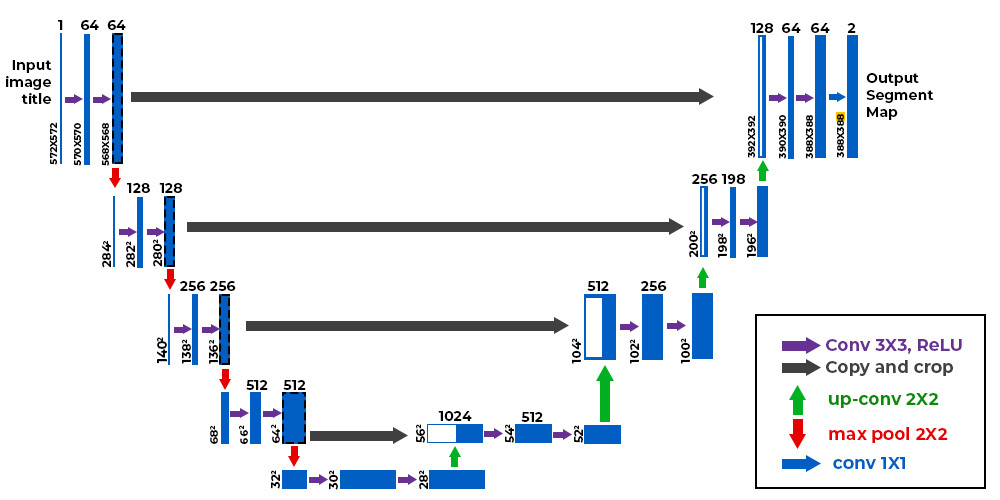

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, 16)
        self.enc2 = ConvBlock(16, 32)
        self.enc3 = ConvBlock(32, 64)
        self.bottleneck = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x1 = self.enc1(x)              # 16 channels x 600
        x2 = self.enc2(self.pool(x1))  # 32 channels x 300
        x3 = self.enc3(self.pool(x2))  # 64 channels x 150
        x4 = self.bottleneck(self.pool(x3))  # 128 channels x 75

        return x1, x2, x3, x4

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(2*out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

In [ ]:
class UNetDecoder(nn.Module):
    def __init__(self, in_channels = 128):
        super().__init__()

        self.decode1 = DecoderBlock(in_channels=in_channels, out_channels=in_channels//2)
        self.decode2 = DecoderBlock(in_channels=in_channels//2, out_channels=in_channels//4)
        self.decode3 = DecoderBlock(in_channels=in_channels//4, out_channels=in_channels//8)

        self.final_conv = nn.Conv2d(in_channels//8, 1, kernel_size=1)  # Output 1 channel for binary segmentation

    def forward(self, x4,x3, x2, x1):
        x = self.decode1(x4, x3) # 64 channels x 150
        x = self.decode2(x, x2)  # 32 channels x 300
        x = self.decode3(x, x1)  # 16 channels x 600
        x = self.final_conv(x).squeeze(1) #1 channel x 600
        return x

In [ ]:
class Classifier(nn.Module):
    def __init__(self, in_channels = 32, num_classes = 3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels*2, 3)
        self.conv2 = nn.Conv2d(in_channels*2, in_channels, 3)
        self.conv3 = nn.Conv2d(in_channels, num_classes, 3)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2, stride = 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2, stride = 2)
        x = F.adaptive_avg_pool2d(self.conv3(x), (1, 1)).squeeze((-1,-2))

        return x

## Classifier

In [ ]:
def train_classifier(encoder, classifier, optim, loss_fn, train_loader, verbose = True):
    total_loss = 0
    accuracy = 0
    total_samples = 0

    encoder.train()
    classifier.train()

    for i in range(train_loader.len):
      #first we predict
      x, y = train_loader.next()
      x = encoder(x.unsqueeze(1))[2]
      y_predict = classifier(x)

      #then we calculate loss
      loss = loss_fn(y_predict, y)

      #then we zero grad the existing gradients
      optim.zero_grad()

      #then we push the new gradients through the backward graph
      loss.backward()

      #then we update the weights
      optim.step()

      #for reporting purposes
      total_loss += loss.item()
      accuracy += (y_predict.argmax(dim = 1) == y).sum().item()
      total_samples += y.shape[0]

    if verbose:
      print(f"Train loss - {total_loss/train_loader.len:4f} | Train accuracy - {accuracy/total_samples:4f}")

def test_classifier(encoder, classifier, loss_fn, test_loader, verbose = True):
    total_loss = 0
    accuracy = 0
    total_samples = 0

    encoder.eval()
    classifier.eval()

    for i in range(test_loader.len):
      #first we predict
      x, y = test_loader.next()
      x = encoder(x.unsqueeze(1))[2]
      y_predict = classifier(x)

      #then we calculate loss
      loss = loss_fn(y_predict, y)

      #we dont update during eval

      # #then we zero grad the existing gradients
      # optim.zero_grad()

      # #then we push the new gradients through the backward graph
      # loss.backward()

      # #then we update the weights
      # optim.step()

      #for reporting purposes
      total_loss += loss.item()
      accuracy += (y_predict.argmax(dim = 1) == y).sum().item()
      total_samples += y.shape[0]

    if verbose:
      print(f"Test loss - {total_loss/train_loader.len:4f} | Test accuracy - {accuracy/total_samples:4f}")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader = BatchLoader(x_train, y_mask_train, y_train, shuffle = True, batch_size = 8, device = device)
test_loader = BatchLoader(x_test, y_mask_test, y_test, shuffle = False, batch_size = 8, device = device)

encoder = UNetEncoder(1).to(device)
classifier = Classifier().to(device)
optim = torch.optim.AdamW(list(encoder.parameters()) + list(classifier.parameters()), lr = 0.001)
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

loss_fn = nn.CrossEntropyLoss(weight = class_weights.to(device))

epochs = 10

for epoch in range(epochs):
    print(f"Epoch - {epoch + 1}\n")
    train_classifier(encoder, classifier, optim, loss_fn, train_loader)
    test_classifier(encoder, classifier, loss_fn, test_loader)
    print("\n")

Epoch - 1

Train loss - 1.081430 | Train accuracy - 0.492674
Test loss - 0.280697 | Test accuracy - 0.627737


Epoch - 2

Train loss - 1.040294 | Train accuracy - 0.584249
Test loss - 0.314815 | Test accuracy - 0.357664


Epoch - 3

Train loss - 0.958114 | Train accuracy - 0.635531
Test loss - 0.325946 | Test accuracy - 0.678832


Epoch - 4

Train loss - 0.957285 | Train accuracy - 0.628205
Test loss - 0.296291 | Test accuracy - 0.576642


Epoch - 5

Train loss - 0.950955 | Train accuracy - 0.677656
Test loss - 0.280040 | Test accuracy - 0.664234


Epoch - 6

Train loss - 0.877334 | Train accuracy - 0.717949
Test loss - 0.339307 | Test accuracy - 0.583942


Epoch - 7

Train loss - 0.881990 | Train accuracy - 0.717949
Test loss - 0.278125 | Test accuracy - 0.700730


Epoch - 8

Train loss - 0.863531 | Train accuracy - 0.705128
Test loss - 0.271328 | Test accuracy - 0.678832


Epoch - 9

Train loss - 0.831069 | Train accuracy - 0.723443
Test loss - 0.290748 | Test accuracy - 0.664234


E

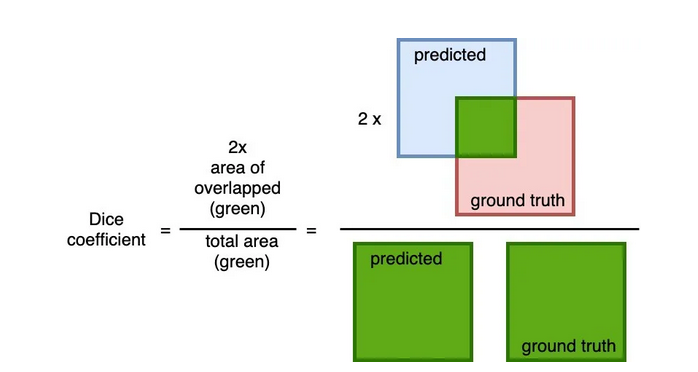

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)  # raw logits to probabilities

        intersection = (preds * targets).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

        return dice_loss

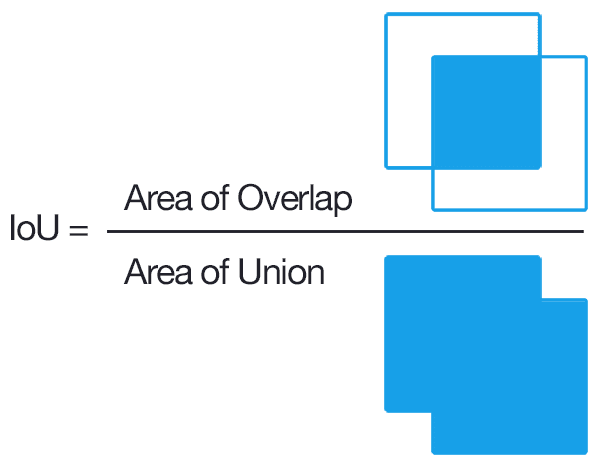

In [ ]:
def calculate_iou(y_pred, y_true, threshold=0.5, eps=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > threshold).float() #making it binaray

    y_pred = y_pred.view(y_pred.shape[0], -1)
    y_true = y_true.view(y_true.shape[0], -1)

    intersection = (y_pred * y_true).sum(dim = 1)
    union = y_pred.sum(dim = 1) + y_true.sum(dim = 1) - intersection

    # Compute IoU
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader = BatchLoader(x_train, y_mask_train, y_train, shuffle = True, batch_size = 8, device = device)
test_loader = BatchLoader(x_test, y_mask_test, y_test, shuffle = False, batch_size = 8, device = device)

encoder = UNetEncoder(1).to(device)
decoder = UNetDecoder().to(device)
optim = torch.optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), lr = 0.05)
dice_loss = DiceLoss()
bce_loss = nn.BCEWithLogitsLoss()

epochs = 25

for epoch in range(epochs):
    print(f"Epoch - {epoch + 1}")

    train_bce_loss = 0
    train_dice_loss = 0
    train_iou = 0

    encoder.train()
    decoder.train()

    for i in range(train_loader.len):
        x, y = train_loader.next('segmentation')
        x1, x2, x3, x4 = encoder(x.unsqueeze(1))
        y_predict = decoder(x4, x3, x2, x1)

        bce = bce_loss(y_predict, y.float())
        dice = dice_loss(y_predict, y)

        loss = 0.2*bce + 0.8*dice

        train_bce_loss += bce
        train_dice_loss += dice
        train_iou += calculate_iou(y_predict, y.float())

        optim.zero_grad()
        loss.backward()
        optim.step()

    print(f"Train BCE loss - {train_bce_loss/train_loader.len:4f} | Train Dice loss - {train_dice_loss/train_loader.len:4f} | Train IoU - {train_iou/train_loader.len:4f}")

    test_bce_loss = 0
    test_dice_loss = 0
    test_iou = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for i in range(test_loader.len):
            x, y = test_loader.next('segmentation')
            x1, x2, x3, x4 = encoder(x.unsqueeze(1))
            y_predict = decoder(x4, x3, x2, x1)

            bce = bce_loss(y_predict, y.float())
            dice = dice_loss(y_predict, y)

            test_bce_loss += bce
            test_dice_loss += dice
            test_iou += calculate_iou(y_predict, y.float())

    print(f"Test BCE loss - {test_bce_loss/test_loader.len:4f} | Test Dice loss - {test_dice_loss/test_loader.len:4f} | Test IoU - {test_iou/test_loader.len:4f}")
    print("\n")


Epoch - 1
Train BCE loss - 0.222949 | Train Dice loss - 0.876903 | Train IoU - 0.242193
Test BCE loss - 6.063138 | Test Dice loss - 0.889527 | Test IoU - 0.063355


Epoch - 2
Train BCE loss - 0.216398 | Train Dice loss - 0.824108 | Train IoU - 0.177594
Test BCE loss - 1.013083 | Test Dice loss - 0.845479 | Test IoU - 0.083007


Epoch - 3
Train BCE loss - 0.208338 | Train Dice loss - 0.828814 | Train IoU - 0.174825
Test BCE loss - 0.167594 | Test Dice loss - 0.882728 | Test IoU - 0.176132


Epoch - 4
Train BCE loss - 0.210782 | Train Dice loss - 0.806228 | Train IoU - 0.186044
Test BCE loss - 0.295164 | Test Dice loss - 0.805822 | Test IoU - 0.136012


Epoch - 5
Train BCE loss - 0.200062 | Train Dice loss - 0.801718 | Train IoU - 0.165760
Test BCE loss - 0.178003 | Test Dice loss - 0.968568 | Test IoU - 0.474428


Epoch - 6
Train BCE loss - 0.189323 | Train Dice loss - 0.814069 | Train IoU - 0.212367
Test BCE loss - 0.423327 | Test Dice loss - 0.801578 | Test IoU - 0.133762


Epoch - 7


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_loader = BatchLoader(x_train, y_mask_train, y_train, shuffle = True, batch_size = 8, device = device)
test_loader = BatchLoader(x_test, y_mask_test, y_test, shuffle = False, batch_size = 8, device = device)

encoder = UNetEncoder(1).to(device)
decoder = UNetDecoder().to(device)
classifier = Classifier(128).to(device)
optim = torch.optim.AdamW(list(encoder.parameters()) + list(decoder.parameters()), lr = 0.005)
dice_loss = DiceLoss()
bce_loss = nn.BCEWithLogitsLoss()

class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

classifier_loss_fn = nn.CrossEntropyLoss(weight = class_weights.to(device))

epochs = 25

for epoch in range(epochs):
    print(f"Epoch - {epoch + 1}")

    train_bce_loss = 0
    train_dice_loss = 0
    train_iou = 0
    train_classifier_loss = 0
    train_correct = 0
    train_samples = 0

    encoder.train()
    decoder.train()

    for i in range(train_loader.len):
        x, y_label, y_mask = train_loader.next('both')
        x1, x2, x3, x4 = encoder(x.unsqueeze(1))
        y_predict_mask = decoder(x4, x3, x2, x1)
        y_predict_label = classifier(x4)

        bce = bce_loss(y_predict_mask, y_mask.float())
        dice = dice_loss(y_predict_mask, y_mask)
        classifier_loss = classifier_loss_fn(y_predict_label, y_label)

        loss = (0.2*bce + 0.8*dice)/2 + 0.5*classifier_loss

        train_bce_loss += bce
        train_dice_loss += dice
        train_iou += calculate_iou(y_predict_mask, y_mask.float())
        train_classifier_loss += classifier_loss
        train_correct += (y_predict_label.argmax(dim = 1) == y_label).sum().item()
        train_samples += y_label.shape[0]

        optim.zero_grad()
        loss.backward()
        optim.step()

    print(f"Train BCE loss - {train_bce_loss/train_loader.len:4f}")
    print(f"Train Dice loss - {train_dice_loss/train_loader.len:4f}")
    print(f"Train IoU - {train_iou/train_loader.len:4f}")
    print(f"Train Classifier loss - {train_classifier_loss/train_loader.len:4f}")
    print(f"Train accuracy - {train_correct/train_samples:4f}")

    test_bce_loss = 0
    test_dice_loss = 0
    test_iou = 0
    test_classifier_loss = 0
    test_correct = 0
    test_samples = 0

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        for i in range(test_loader.len):
            x, y_label, y_mask = test_loader.next('both')
            x1, x2, x3, x4 = encoder(x.unsqueeze(1))
            y_predict_mask = decoder(x4, x3, x2, x1)
            y_predict_label = classifier(x4)

            bce = bce_loss(y_predict_mask, y_mask.float())
            dice = dice_loss(y_predict_mask, y_mask)
            classifier_loss = classifier_loss_fn(y_predict_label, y_label)

            test_bce_loss += bce
            test_dice_loss += dice
            test_iou += calculate_iou(y_predict_mask, y_mask.float())
            test_classifier_loss += classifier_loss
            test_correct += (y_predict_label.argmax(dim = 1) == y_label).sum().item()
            test_samples += y_label.shape[0]

        print(f"\nTest BCE loss - {test_bce_loss/test_loader.len:4f}")
        print(f"Test Dice loss - {test_dice_loss/test_loader.len:4f}")
        print(f"Test IoU - {test_iou/test_loader.len:4f}")
        print(f"Test Classifier loss - {test_classifier_loss/test_loader.len:4f}")
        print(f"Test accuracy - {test_correct/test_samples:4f}\n")

Epoch - 1
Train BCE loss - 0.273973
Train Dice loss - 0.905678
Train IoU - 0.097099
Train Classifier loss - 1.088822
Train accuracy - 0.472313

Test BCE loss - 0.404349
Test Dice loss - 0.857667
Test IoU - 0.080565
Test Classifier loss - 1.101753
Test accuracy - 0.231884

Epoch - 2
Train BCE loss - 0.184095
Train Dice loss - 0.852946
Train IoU - 0.159611
Train Classifier loss - 1.072361
Train accuracy - 0.605863

Test BCE loss - 0.239185
Test Dice loss - 0.827146
Test IoU - 0.091796
Test Classifier loss - 1.031246
Test accuracy - 0.492754

Epoch - 3
Train BCE loss - 0.183974
Train Dice loss - 0.834869
Train IoU - 0.167302
Train Classifier loss - 1.058303
Train accuracy - 0.627036

Test BCE loss - 0.249426
Test Dice loss - 0.933823
Test IoU - 0.024473
Test Classifier loss - 1.139844
Test accuracy - 0.260870

Epoch - 4
Train BCE loss - 0.182742
Train Dice loss - 0.834736
Train IoU - 0.219481
Train Classifier loss - 1.055490
Train accuracy - 0.609121

Test BCE loss - 0.220734
Test Dice lo